### Exploratory Data Analysis EDA - Health Insurane Data 

[reference](https://www.kaggle.com/code/anchalnigam1/in-depth-analysis-of-us-health-insurance-dataset)  
[reference_2](https://www.kaggle.com/code/kooshanghaziani/linear-regression-of-health-insurance-cost)

In [2]:
### import required Liabraries 
import pandas as pd 
# import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'C:\Users\HP\Documents\PW Skills\Project\Health Insurance\data.csv')
data = pd.read_csv('data.csv')
df.head()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


In [4]:
df.shape 

(15000, 13)

In [5]:
df.columns

Index(['age', 'sex', 'weight', 'bmi', 'hereditary_diseases',
       'no_of_dependents', 'smoker', 'city', 'bloodpressure', 'diabetes',
       'regular_ex', 'job_title', 'claim'],
      dtype='object')

### Ditribute the columnms in categorical and numerical columns

In [6]:
df.head(3)

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2


In [7]:
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'O'] 
numerical_feature = [feature for feature in df.columns if df[feature].dtypes != 'O']


In [8]:
df.dtypes

age                    float64
sex                     object
weight                   int64
bmi                    float64
hereditary_diseases     object
no_of_dependents         int64
smoker                   int64
city                    object
bloodpressure            int64
diabetes                 int64
regular_ex               int64
job_title               object
claim                  float64
dtype: object

In [9]:
## Data Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


### Check for duplicates record 

In [10]:
df.duplicated().any() # Check wheather there is any duplicated value is present or not

np.True_

In [11]:
# Number of duplicated values present in the data
df.duplicated().sum()

np.int64(1096)

In [12]:
# diplay all the duplicated values 
df[df.duplicated(keep=False)]

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
19,52.0,female,76,38.4,NoDisease,2,0,Stamford,48,1,0,Manager,11396.9
51,48.0,female,70,28.9,NoDisease,1,0,KanasCity,72,0,0,Architect,9249.5
72,38.0,female,79,40.2,NoDisease,0,0,Oxnard,68,1,0,FashionDesigner,5401.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14966,46.0,male,46,22.3,NoDisease,0,0,Louisville,72,1,0,Academician,7147.1
14971,18.0,female,53,27.3,NoDisease,3,1,Boston,85,1,0,Student,18223.5
14987,47.0,male,94,47.5,NoDisease,1,0,Raleigh,61,1,0,Academician,8083.9
14989,44.0,male,90,38.1,NoDisease,1,0,Georgia,76,1,0,Engineer,7152.7


In [13]:
# Check the duplicated values 
# df[(df['claim']==13112.6) & (df['city'] == 'NewYork')]

In [14]:
# Show anly the dupicated values 
df[df.duplicated()]

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
605,46.0,female,68,NaN,NoDisease,2,0,LosAngeles,60,1,0,Dancer,8825.1
608,27.0,female,82,NaN,NoDisease,3,0,Oceanside,82,1,1,Architect,18804.8
898,48.0,female,67,33.1,Alzheimer,0,1,Cincinnati,70,1,0,ITProfessional,40974.2
919,26.0,male,56,23.7,NoDisease,2,0,Kingman,72,1,0,HomeMakers,3484.3
970,48.0,female,70,28.9,NoDisease,1,0,KanasCity,72,0,0,Architect,9249.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14966,46.0,male,46,22.3,NoDisease,0,0,Louisville,72,1,0,Academician,7147.1
14971,18.0,female,53,27.3,NoDisease,3,1,Boston,85,1,0,Student,18223.5
14987,47.0,male,94,47.5,NoDisease,1,0,Raleigh,61,1,0,Academician,8083.9
14989,44.0,male,90,38.1,NoDisease,1,0,Georgia,76,1,0,Engineer,7152.7


In [15]:
# drop duplicates
df.drop_duplicates(inplace=True)

In [16]:
df.shape

(13904, 13)

### Missing Values 

In [17]:
# percentage of missing values in each column
df.isnull().sum()/df.shape[0] *100

age                    2.596375
sex                    0.000000
weight                 0.000000
bmi                    6.480150
hereditary_diseases    0.000000
no_of_dependents       0.000000
smoker                 0.000000
city                   0.000000
bloodpressure          0.000000
diabetes               0.000000
regular_ex             0.000000
job_title              0.000000
claim                  0.000000
dtype: float64

In [18]:
# replace the missing values in age column with mean age 
df['age'].isnull().sum()

np.int64(361)

In [19]:
df['age'].fillna(df['age'].mean(), inplace=True )
df['bmi'].fillna(df['bmi'].mean(), inplace=True)

In [20]:
df.isnull().sum() # now there is no null values present in the data 

age                    0
sex                    0
weight                 0
bmi                    0
hereditary_diseases    0
no_of_dependents       0
smoker                 0
city                   0
bloodpressure          0
diabetes               0
regular_ex             0
job_title              0
claim                  0
dtype: int64

### Statistical measures

In [21]:
# df.describe(include="number")

In [22]:
df[numerical_feature].describe()

,age,weight,bmi,no_of_dependents,smoker,bloodpressure,diabetes,regular_ex,claim
count,13904.000000,13904.000000,13904.000000,13904.000000,13904.000000,13904.000000,13904.000000,13904.000000,13904.000000
mean,39.556598,64.894347,30.273483,1.126438,0.200662,68.657652,0.771145,0.230725,13431.813744
std,13.827948,13.675070,5.923446,1.225661,0.400510,19.430514,0.420111,0.421312,12142.099413
min,18.000000,34.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1121.900000
25%,27.000000,54.000000,25.900000,0.000000,0.000000,64.000000,1.000000,0.000000,4883.900000
50%,40.000000,63.000000,29.900000,1.000000,0.000000,71.000000,1.000000,0.000000,9567.000000
75%,51.000000,76.000000,34.100000,2.000000,0.000000,80.000000,1.000000,0.000000,16657.700000
max,64.000000,95.000000,53.100000,5.000000,1.000000,122.000000,1.000000,1.000000,63770.400000


In [23]:
df[categorical_feature].describe()

,sex,hereditary_diseases,city,job_title
count,13904,13904,13904,13904
unique,2,10,91,35
top,female,NoDisease,Nashville,Student
freq,7091,12965,270,1220


### Countplot of categorical feature 

In [24]:
categorical_feature

['sex', 'hereditary_diseases', 'city', 'job_title']

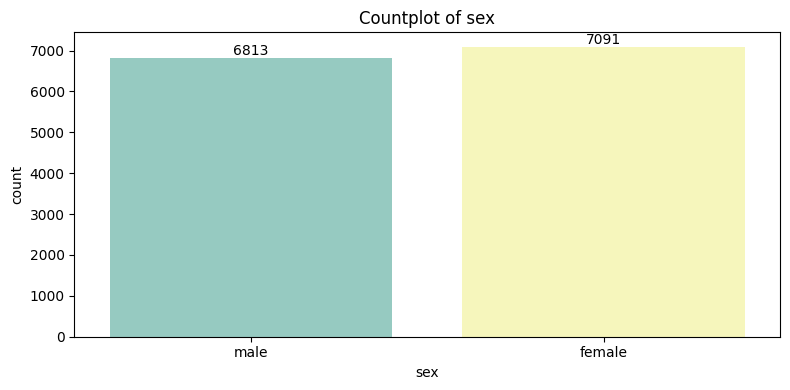

In [25]:
specific_feature = 'sex'

for feature in categorical_feature:
    if feature == specific_feature:
        plt.figure(figsize=(8,4))
        ax = sns.countplot(x=feature, data=df, palette='Set3')
    
        for bars in ax.containers:
            ax.bar_label(bars)
            
        plt.title(f'Countplot of {specific_feature}')
        plt.tight_layout()
        

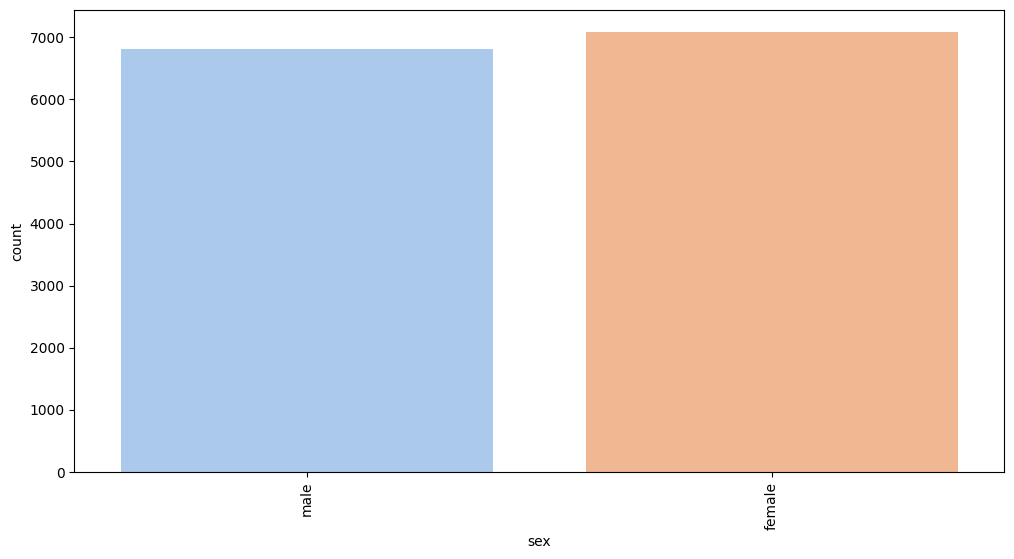

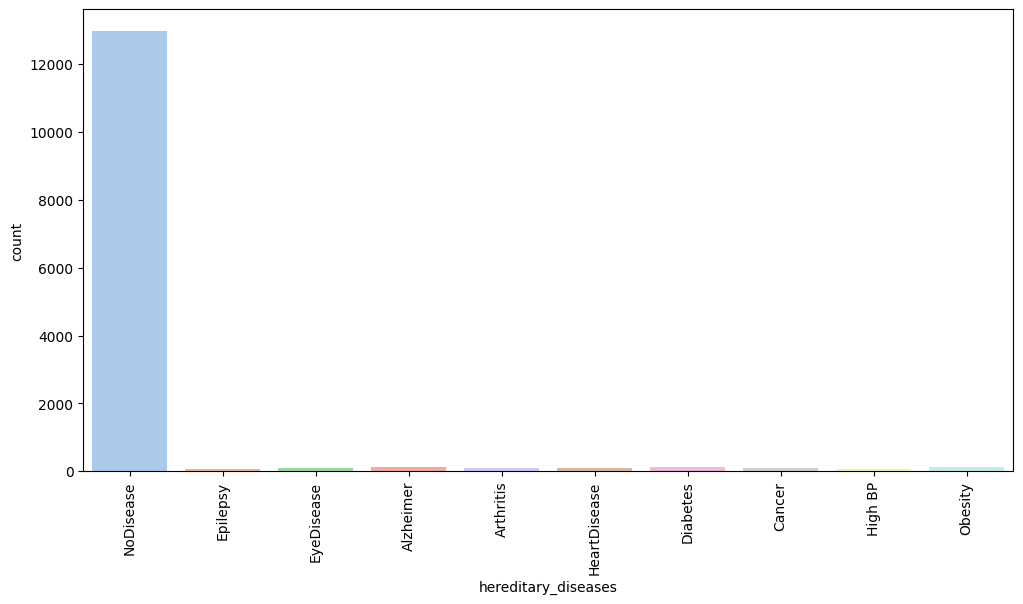

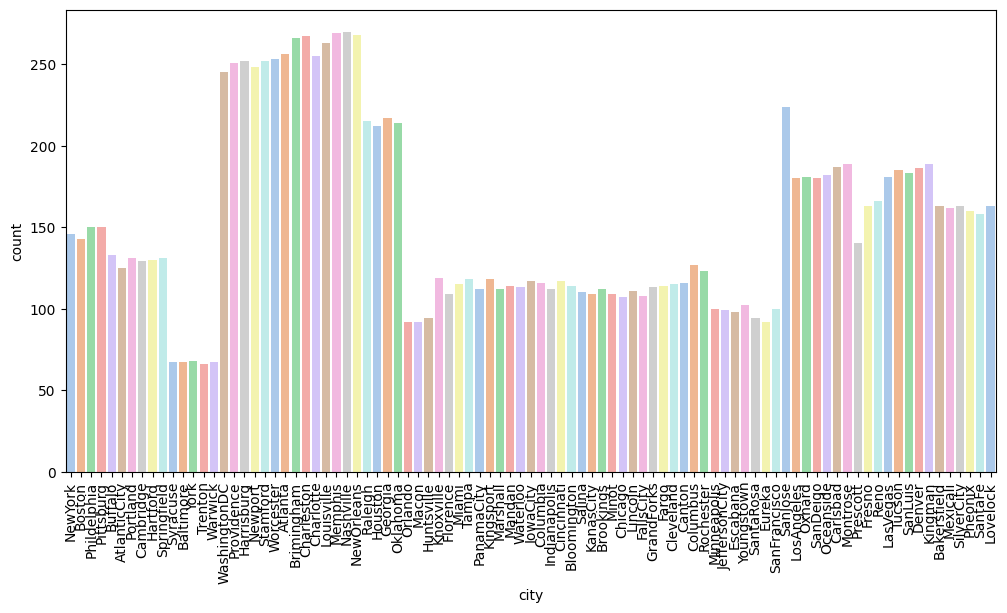

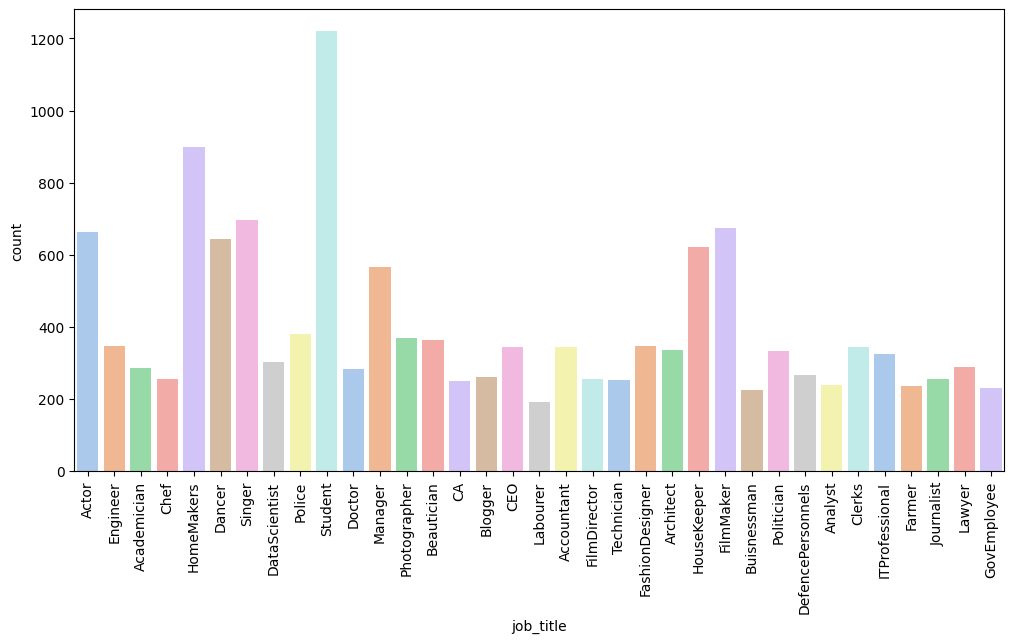

In [26]:
### Countplot of all the categorical column
for feature in categorical_feature:
    plt.figure(figsize=(12, 6))
    
    sns.countplot(x=feature,palette='pastel',data=df)
    plt.xticks(rotation = 90)

In [27]:
numerical_feature

['age',
 'weight',
 'bmi',
 'no_of_dependents',
 'smoker',
 'bloodpressure',
 'diabetes',
 'regular_ex',
 'claim']

In [28]:
# for feature in numerical_feature:
#     plt.figure(figsize=(10, 5))
    
#     sns.histplot(data=df,x=feature,kde=True)
        
#     plt.title(f'Distribution of {feature}')
#     plt.ylabel('Frequency')

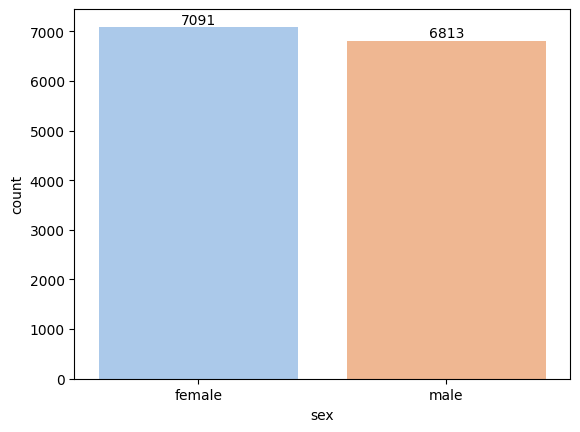

In [29]:
ax = sns.barplot(df['sex'].value_counts(),palette='pastel')
for bar in ax.containers:
    ax.bar_label(bar)

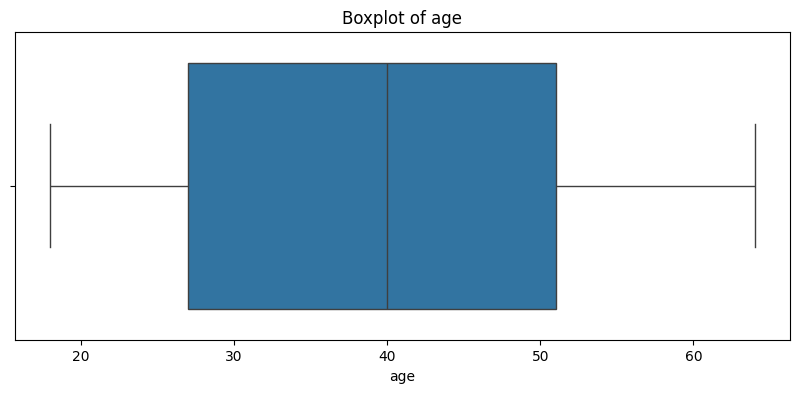

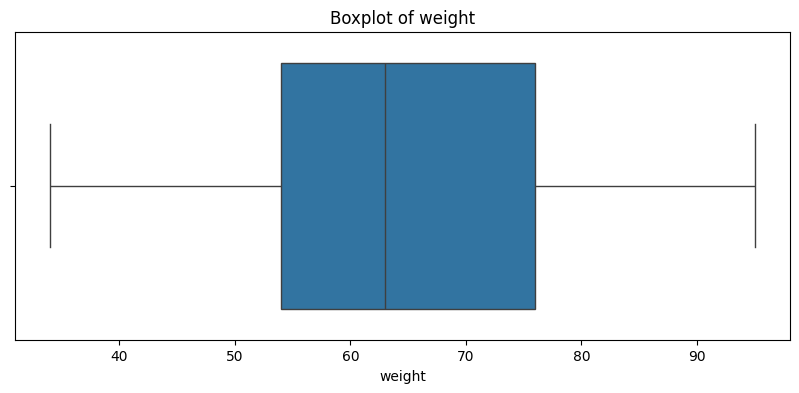

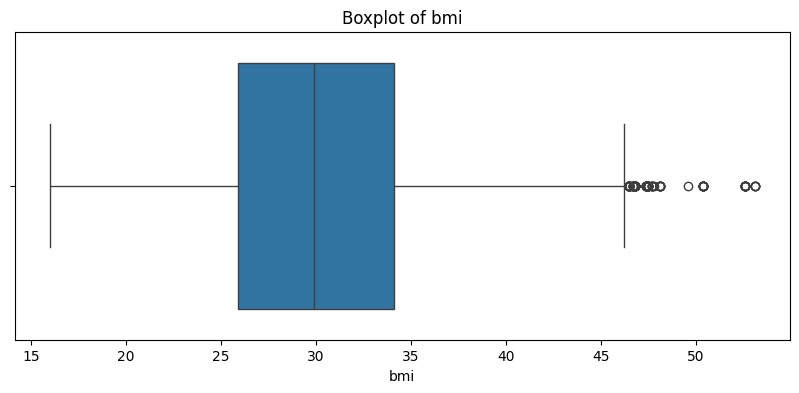

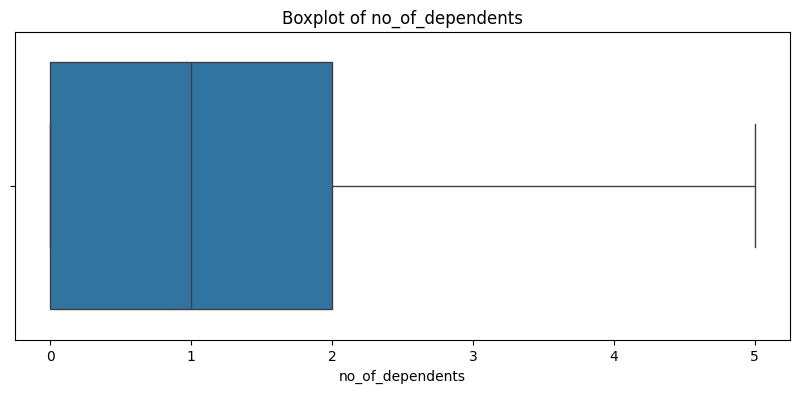

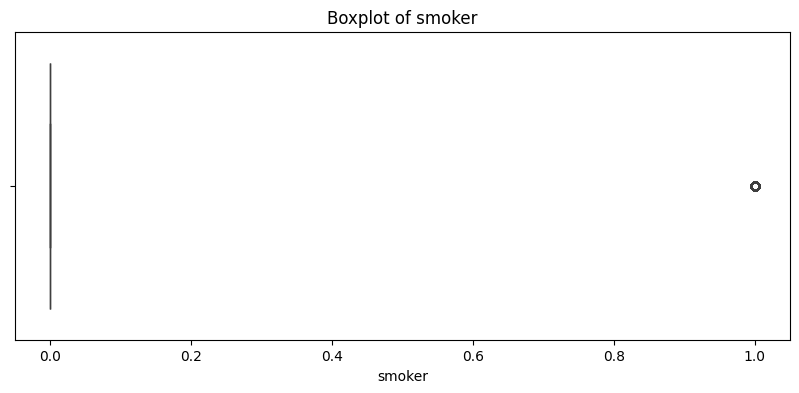

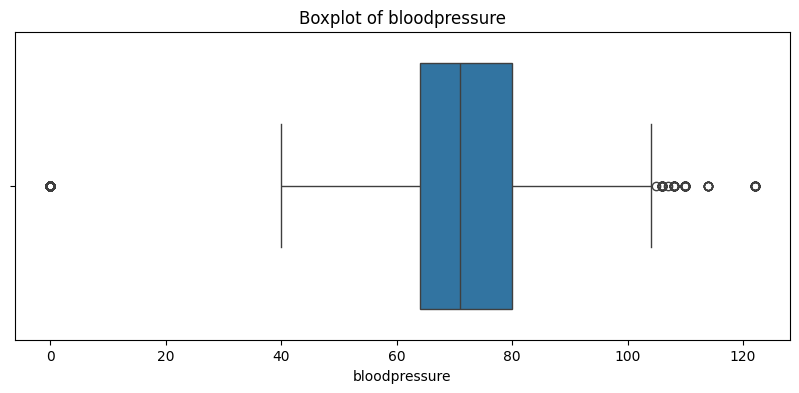

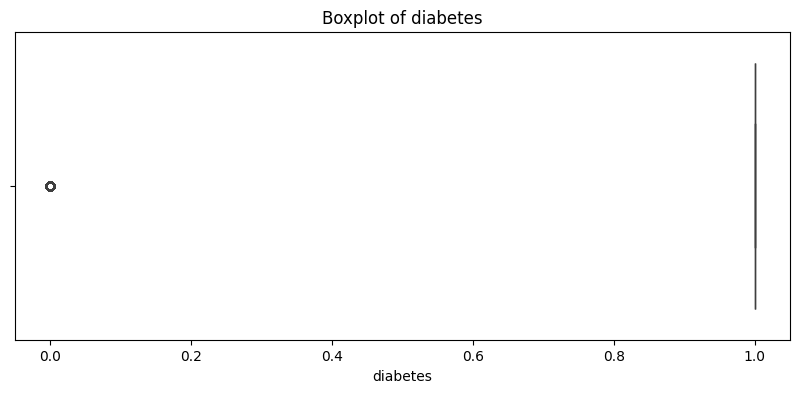

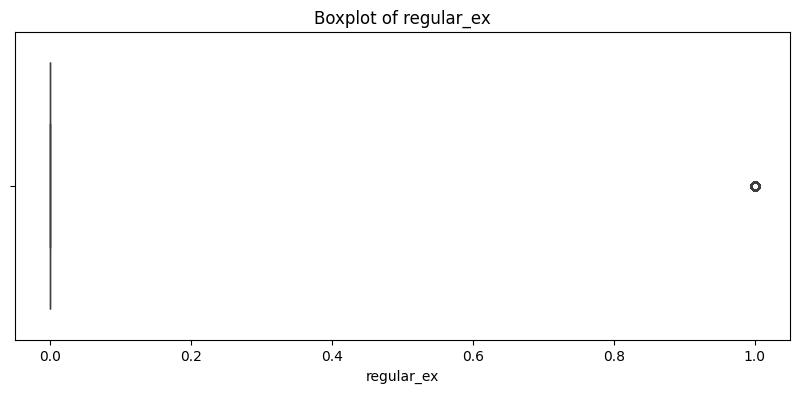

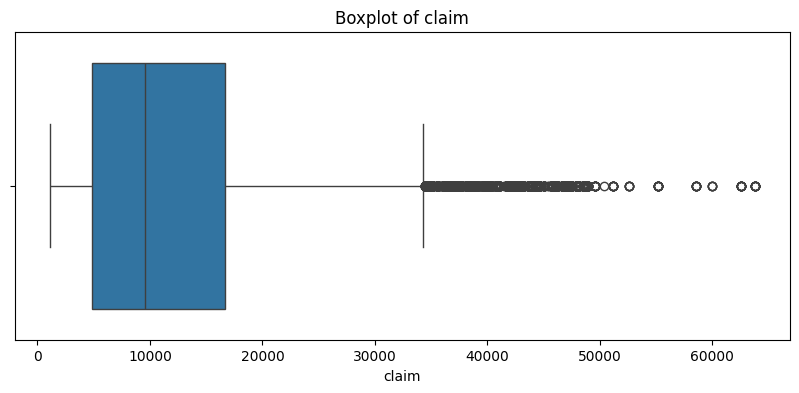

In [30]:
# # it's not clearly visible so now we check all the columns one by one
for feature in numerical_feature:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=feature, data=df)
    plt.title(f'Boxplot of {feature}')

### Outlier treatment 

In [31]:
## Outliers detected in BMI, BP and Claim

In [32]:
import numpy as np

In [33]:
q1 = df['claim'].quantile(0.25)
q3 = df['claim'].quantile(0.75)
iqr = q3 - q1

lower_fense = q1 - 1.5*iqr
upper_fense = q3 + 1.5*iqr

In [34]:
df = df[(df.claim >= lower_fense) & (df.claim <= upper_fense)]

In [35]:
df.shape

(12414, 13)

<Axes: xlabel='bloodpressure'>

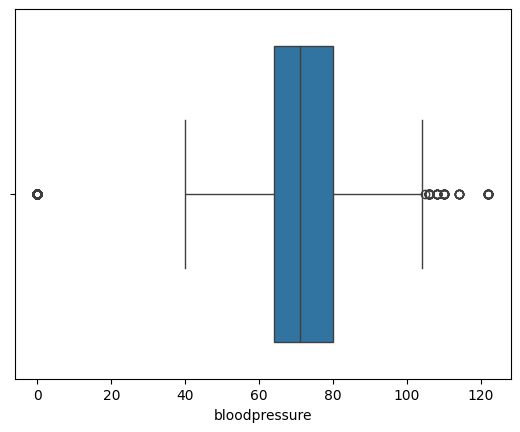

In [36]:
sns.boxplot(x = 'bloodpressure', data = df)

In [37]:
q1 = df['bloodpressure'].quantile(0.25)
q3 = df['bloodpressure'].quantile(0.75)
iqr = q3 - q1

lower_fense = q1 - 1.5*iqr
upper_fense = q3 + 1.5*iqr

df = df[(df['bloodpressure'] >= lower_fense) & (df['bloodpressure'] <= upper_fense)]

<Axes: xlabel='bmi'>

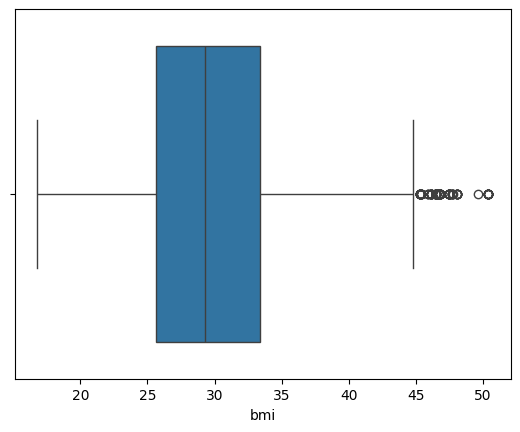

In [38]:
sns.boxplot(x = 'bmi', data = df)

In [39]:
q1 = df['bmi'].quantile(0.25)
q3 = df['bmi'].quantile(0.75)
iqr = q3 - q1

lower_fense = q1 - 1.5*iqr
upper_fense = q3 + 1.5*iqr

df = df[(df['bmi'] >= lower_fense) & (df['bmi'] <= upper_fense)]

## Univaraite Analysis - Categorical columns 

In [40]:
categorical_feature

['sex', 'hereditary_diseases', 'city', 'job_title']

In [41]:
des_cat_feature = [i for i in categorical_feature if df[i].nunique() < 20 ]

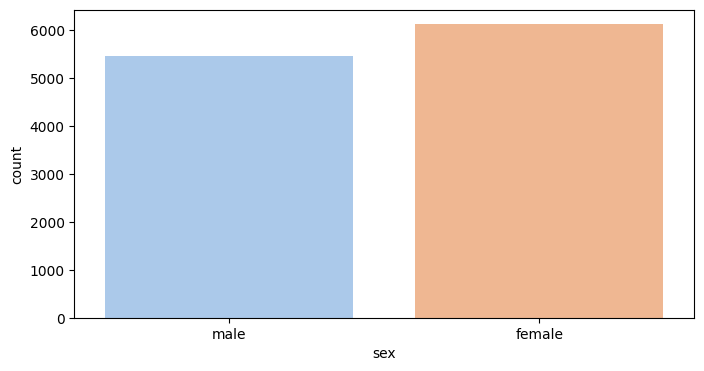

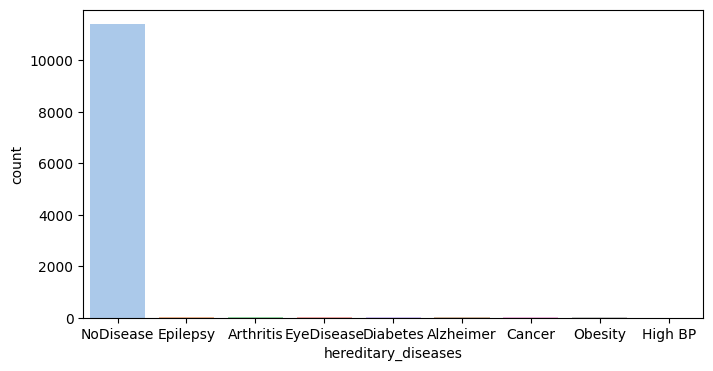

In [42]:
for i in des_cat_feature:
    plt.figure(figsize=(8,4))
    sns.countplot(x = i, data = df, palette = 'pastel')
    

In [43]:
### Insights
# major customers have no disease 

### numerical feature 

In [44]:
df[numerical_feature].describe().T

,count,mean,std,min,25%,50%,75%,max
age,11561.0,39.274486,13.908358,18.0,27.0,39.556598,51.0,64.0
weight,11561.0,64.513796,13.628918,40.0,54.0,63.000000,75.0,95.0
bmi,11561.0,29.592207,5.545757,16.8,25.6,29.100000,33.3,44.8
no_of_dependents,11561.0,1.106046,1.235784,0.0,0.0,1.000000,2.0,5.0
smoker,11561.0,0.110804,0.313902,0.0,0.0,0.000000,0.0,1.0
bloodpressure,11561.0,71.944382,11.031158,40.0,64.0,72.000000,80.0,104.0
diabetes,11561.0,0.750541,0.432719,0.0,1.0,1.000000,1.0,1.0
regular_ex,11561.0,0.246086,0.430748,0.0,0.0,0.000000,0.0,1.0
claim,11561.0,10040.572130,7276.519594,1131.5,4504.7,8516.800000,13019.2,34303.2


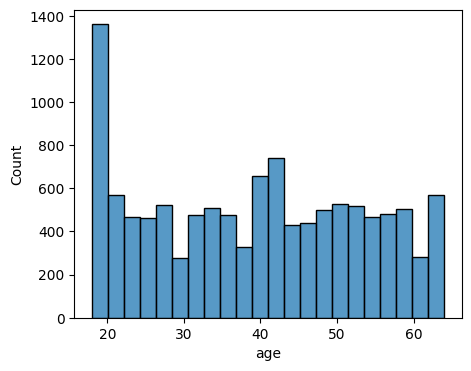

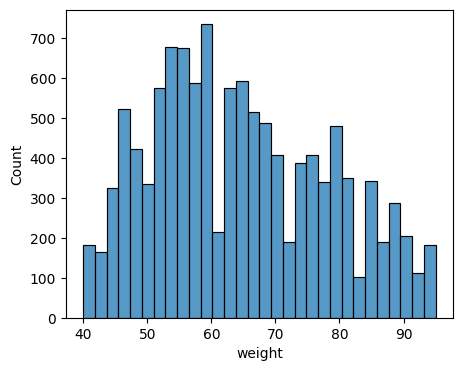

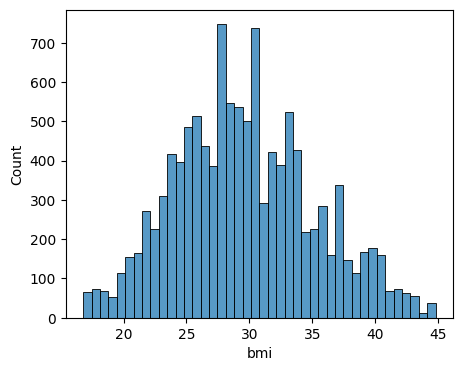

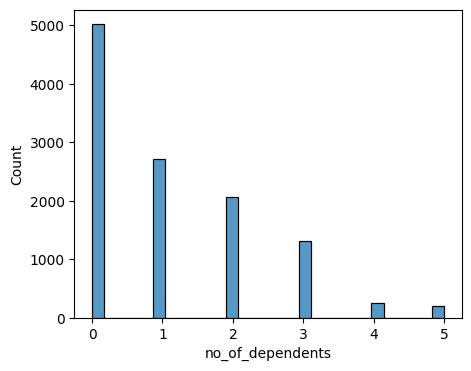

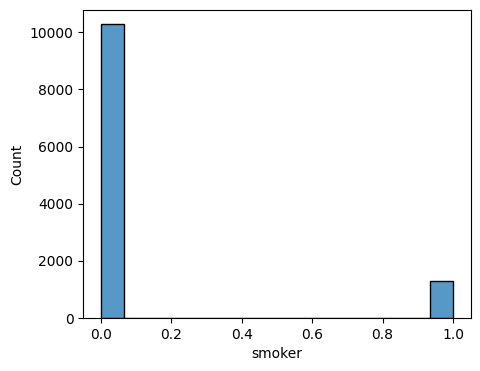

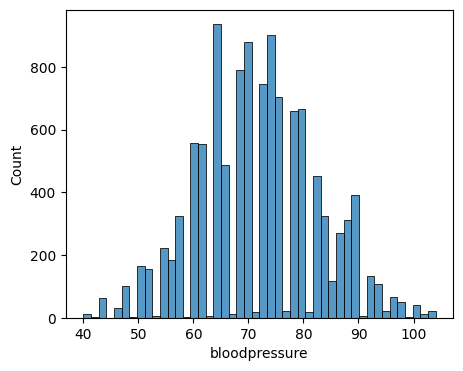

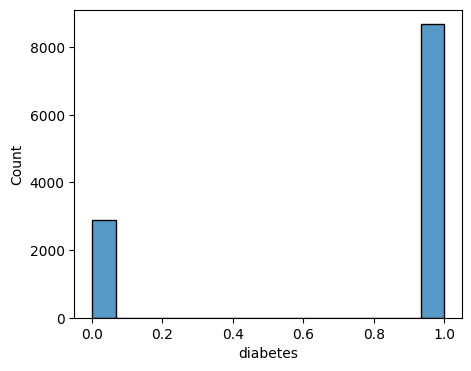

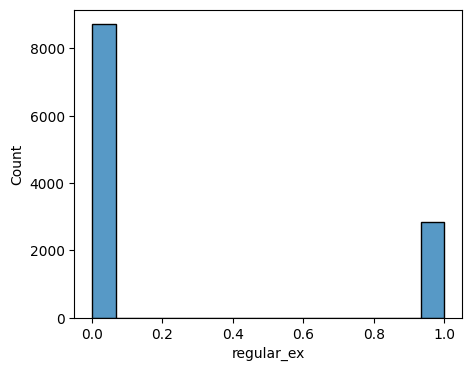

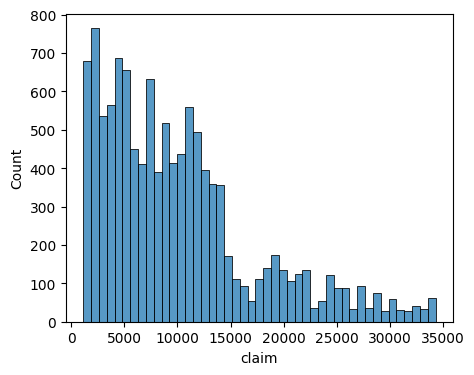

In [45]:
for i in numerical_feature:
    plt.figure(figsize=(5,4))
    sns.histplot(x=i, data=df)

<Axes: >

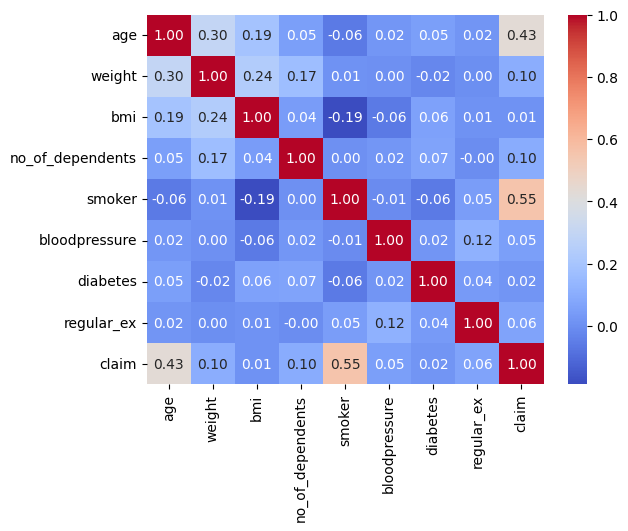

In [46]:
sns.heatmap(df[numerical_feature].corr(),cmap='coolwarm',annot=True, fmt='.2f')

### Numerical feature 

In [47]:
### We can see that there is high corr in 
# BMI and claim , 
# smoker and claim
# BMI and weight
# BMI and age 
# Diabetes and claim 

Insights : We can see that as the age increases claim is also increases


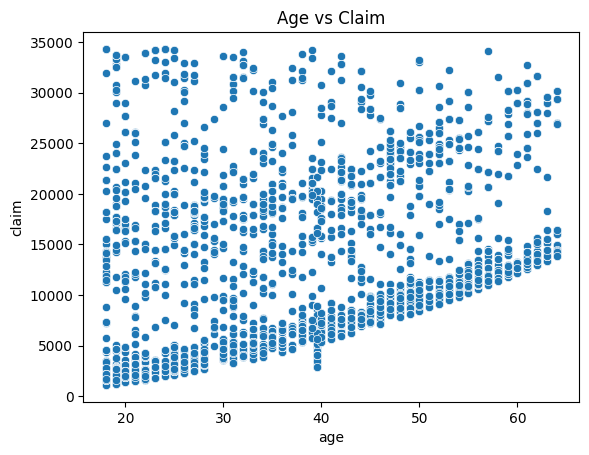

In [48]:
sns.scatterplot(x='age',y='claim',data=df)
print(f'Insights : We can see that as the age increases claim is also increases')
plt.title('Age vs Claim')
plt.show()

df

In [49]:
df

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7
5,42.0,female,89,37.9,NoDisease,0,0,AtlanticCity,78,0,0,Dancer,6474.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14993,56.0,female,55,25.7,NoDisease,0,0,Huntsville,80,1,0,Dancer,11454.0
14995,39.0,male,49,28.3,NoDisease,1,1,Florence,54,1,0,FilmMaker,21082.2
14996,39.0,male,74,29.6,NoDisease,4,0,Miami,64,1,0,Student,7512.3
14998,52.0,male,88,36.7,NoDisease,0,0,PanamaCity,70,1,0,Farmer,9144.6


In [50]:
smoker_df = df.groupby('smoker')['claim'].mean().reset_index()
smoker_df

,smoker,claim
0,0,8616.252870
1,1,21470.706401


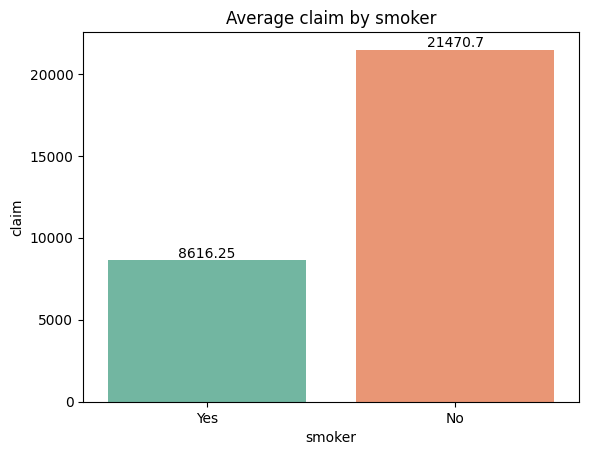

In [51]:
ax = sns.barplot(x='smoker', y= 'claim', data = smoker_df,palette='Set2')
for bar in ax.containers:
    ax.bar_label(bar)
    
ax.set_xticks([0,1])
ax.set_xticklabels(['Yes','No'])

plt.title('Average claim by smoker')
plt.show()


### Claim by male and female 

In [52]:
df.groupby('sex')['claim'].mean().reset_index()

,sex,claim
0,female,10081.318054
1,male,9994.820878


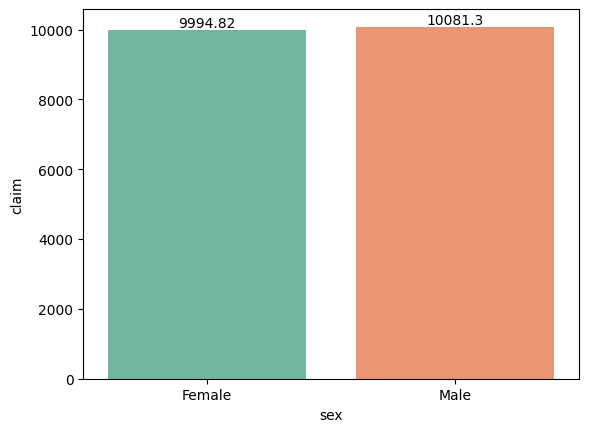

In [53]:
ax = sns.barplot(x='sex', y='claim', ci=None ,palette='Set2', data= df)
for bar in ax.containers:
    ax.bar_label(bar)
ax.set_xticks([0,1])
ax.set_xticklabels(['Female','Male'])
plt.show()

In [54]:
df

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7
5,42.0,female,89,37.9,NoDisease,0,0,AtlanticCity,78,0,0,Dancer,6474.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14993,56.0,female,55,25.7,NoDisease,0,0,Huntsville,80,1,0,Dancer,11454.0
14995,39.0,male,49,28.3,NoDisease,1,1,Florence,54,1,0,FilmMaker,21082.2
14996,39.0,male,74,29.6,NoDisease,4,0,Miami,64,1,0,Student,7512.3
14998,52.0,male,88,36.7,NoDisease,0,0,PanamaCity,70,1,0,Farmer,9144.6


In [59]:
pd.crosstab(df['hereditary_diseases'],df['diabetes'],normalize='index')

diabetes,0,1
hereditary_diseases,,
Alzheimer,0.054054,0.945946
Arthritis,0.705882,0.294118
Cancer,0.200000,0.800000
Diabetes,0.173913,0.826087
Epilepsy,0.357143,0.642857
EyeDisease,0.777778,0.222222
High BP,0.666667,0.333333
NoDisease,0.247698,0.752302
Obesity,0.695652,0.304348


In [77]:
disease = df.groupby('hereditary_diseases')['claim'].mean().reset_index().sort_values(ascending=False,by='claim')
disease

,hereditary_diseases,claim
0,Alzheimer,31713.497297
3,Diabetes,28323.069565
2,Cancer,27449.124000
8,Obesity,24878.447826
4,Epilepsy,24795.521429
5,EyeDisease,23363.555556
1,Arthritis,21756.052941
6,High BP,19844.833333
7,NoDisease,9806.045373


Text(0.5, 1.0, 'Claim by each disease')

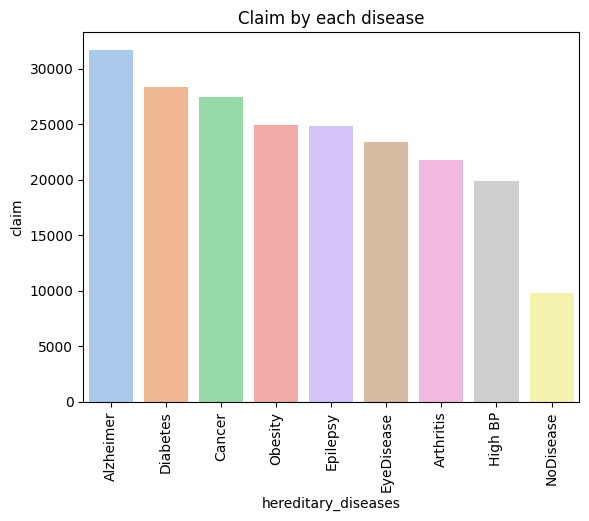

In [89]:
sns.barplot(x='hereditary_diseases', y='claim',ci=None, palette='pastel',data=disease)
plt.xticks(rotation=90)
plt.title('Claim by each disease')

In [87]:
## Claim by top professions 
top_proffession = df.groupby('job_title')['claim'].mean().sort_values(ascending=False).head(10).reset_index()
top_proffession

,job_title,claim
0,FilmMaker,13440.617282
1,Manager,12403.760345
2,Photographer,12030.919536
3,Architect,11977.738431
4,HouseKeeper,11920.188078
5,Actor,11732.706061
6,Beautician,11573.709215
7,Dancer,11425.764801
8,FashionDesigner,11407.461661
9,HomeMakers,11216.503349


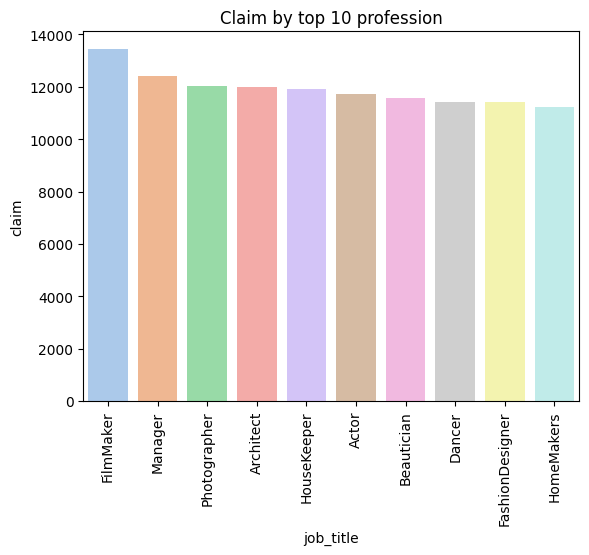

In [94]:
sns.barplot(x='job_title', y='claim',palette='pastel',data=top_proffession)
plt.title('Claim by top 10 profession')
plt.xticks(rotation = 90)
plt.show()

In [96]:
## Claim by top professions 
top_city = df.groupby('city')['claim'].mean().sort_values(ascending=False).head(10).reset_index()
top_city

,city,claim
0,SantaRosa,11869.091026
1,Kingsport,11592.305051
2,Warwick,11551.800000
3,Indianapolis,11400.834091
4,Oceanside,11327.693548
5,Buffalo,11259.383178
6,Huntsville,11186.440000
7,Tucson,11010.163265
8,Chicago,10887.102299
9,Harrisburg,10870.283562


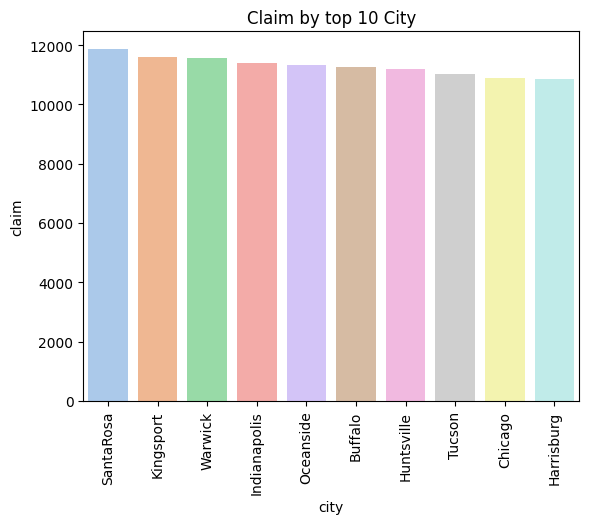

In [99]:
sns.barplot(x='city', y='claim',palette='pastel',data=top_city)
plt.title('Claim by top 10 City')
plt.xticks(rotation = 90)
plt.show()

In [100]:
df

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7
5,42.0,female,89,37.9,NoDisease,0,0,AtlanticCity,78,0,0,Dancer,6474.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14993,56.0,female,55,25.7,NoDisease,0,0,Huntsville,80,1,0,Dancer,11454.0
14995,39.0,male,49,28.3,NoDisease,1,1,Florence,54,1,0,FilmMaker,21082.2
14996,39.0,male,74,29.6,NoDisease,4,0,Miami,64,1,0,Student,7512.3
14998,52.0,male,88,36.7,NoDisease,0,0,PanamaCity,70,1,0,Farmer,9144.6


<Axes: >

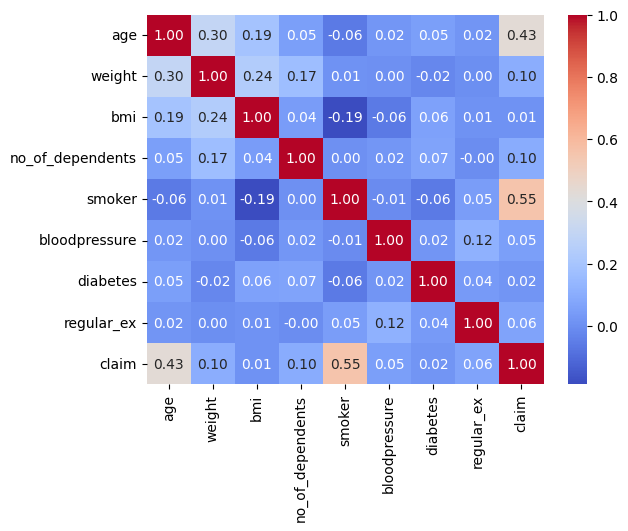

In [106]:
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm',fmt='.2f')

### Insights 
1. A person having Alziemer disease has high claim
2. SantaRosa has highest claim 
3. As the age increases claim is also increases
4. Claim by smoker is high 
